---
## Preprocessing Techniques for Data Analysis
---

#### Import the libraries

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
%reload_ext watermark
%watermark -a "Marcus Rangel"

Author: Marcus Rangel



#### Load the data

In [3]:
# load the dataset
df_psycho_test = pd.read_csv("dataset.csv")

In [4]:
# type
type(df_psycho_test)

pandas.DataFrame

In [5]:
# shape
df_psycho_test.shape

(500, 5)

In [6]:
# columns
df_psycho_test.columns

Index(['Idade', 'Salario', 'Genero', 'Escolaridade',
       'Score_Exame_Psicotecnico'],
      dtype='str')

In [7]:
# first 5 rows of the dataframe
df_psycho_test.head()

,Idade,Salario,Genero,Escolaridade,Score_Exame_Psicotecnico
0,58,30404.959339,Masculino,Médio,56.0
1,48,20886.502401,Feminino,Médio,NaN
2,34,15959.388748,Masculino,Médio,57.0
3,62,28534.995327,Outro,Superior,68.0
4,27,10553.176215,Outro,Fundamental,44.0


In [8]:
# random sample of the dataframe
df_psycho_test.sample(10)

,Idade,Salario,Genero,Escolaridade,Score_Exame_Psicotecnico
410,64,36620.135096,Outro,Médio,74.0
486,43,24609.049811,Outro,Fundamental,30.0
17,21,11086.636917,Feminino,Médio,78.0
127,33,NaN,Outro,Médio,58.0
29,46,21448.666217,Feminino,Médio,50.0
214,51,18507.162131,Masculino,Médio,60.0
44,33,16879.022791,Outro,Médio,54.0
92,28,9801.390789,Masculino,Médio,70.0
246,59,26240.819461,Outro,Fundamental,23.0
146,56,35511.785260,Masculino,Médio,56.0


In [9]:
# info
df_psycho_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Idade                     500 non-null    int64  
 1   Salario                   450 non-null    float64
 2   Genero                    500 non-null    str    
 3   Escolaridade              500 non-null    str    
 4   Score_Exame_Psicotecnico  470 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 19.7 KB


---
## Exploratory Data Analysis (EDA)
---

In [10]:
# describing non-numeric data (categorical)
df_psycho_test.describe(include = object)

/tmp/ipykernel_394759/2903371256.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_psycho_test.describe(include = object)


,Genero,Escolaridade
count,500,500
unique,3,3
top,Feminino,Médio
freq,169,274


In [11]:
# describing numeric data (numerical)
df_psycho_test.describe()

,Idade,Salario,Score_Exame_Psicotecnico
count,500.000000,450.000000,470.000000
mean,42.848000,21252.781137,61.565957
std,13.189725,8322.933018,17.662523
min,20.000000,-3254.849042,20.000000
25%,31.750000,15139.019963,48.000000
50%,44.000000,21681.102602,61.000000
75%,54.000000,27379.540314,74.000000
max,65.000000,40845.107626,100.000000


## Visualizing the distribution of quantitative variables

In [12]:
df_psycho_test.head()

,Idade,Salario,Genero,Escolaridade,Score_Exame_Psicotecnico
0,58,30404.959339,Masculino,Médio,56.0
1,48,20886.502401,Feminino,Médio,NaN
2,34,15959.388748,Masculino,Médio,57.0
3,62,28534.995327,Outro,Superior,68.0
4,27,10553.176215,Outro,Fundamental,44.0


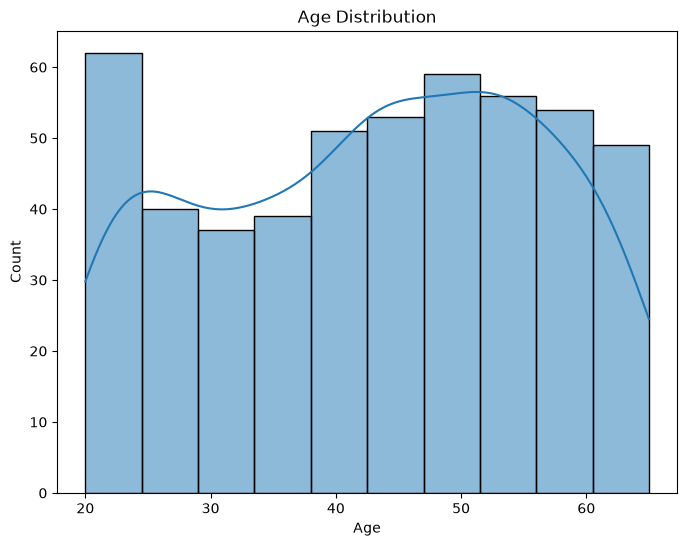

In [ ]:
# plot the score distribution
plt.figure(figsize = (8, 6))
sns.histplot(df_psycho_test["Idade"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

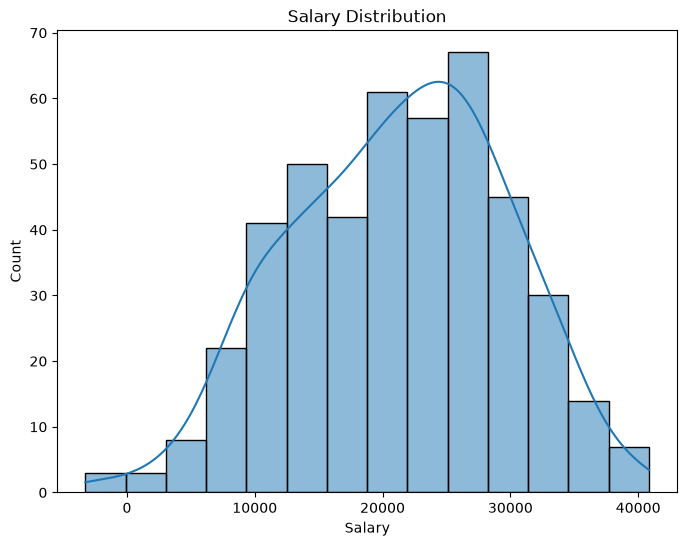

In [19]:
# plot the salary distribution
plt.figure(figsize = (8, 6))
sns.histplot(df_psycho_test["Salario"], kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

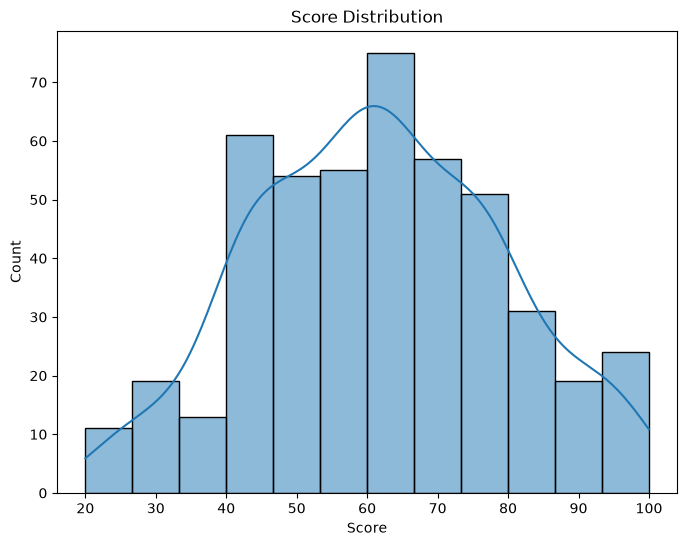

In [21]:
# plot the score distribution
plt.figure(figsize = (8, 6))
sns.histplot(df_psycho_test["Score_Exame_Psicotecnico"], kde=True)
plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

## Visualizing the distribution of qualitatives variables

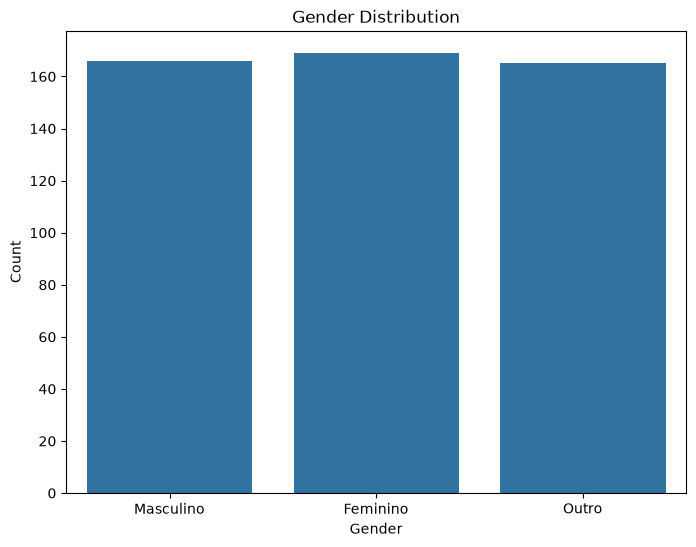

In [23]:
# plot gender distribution
plt.figure(figsize=(8,6))
sns.countplot(data = df_psycho_test, x = "Genero")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

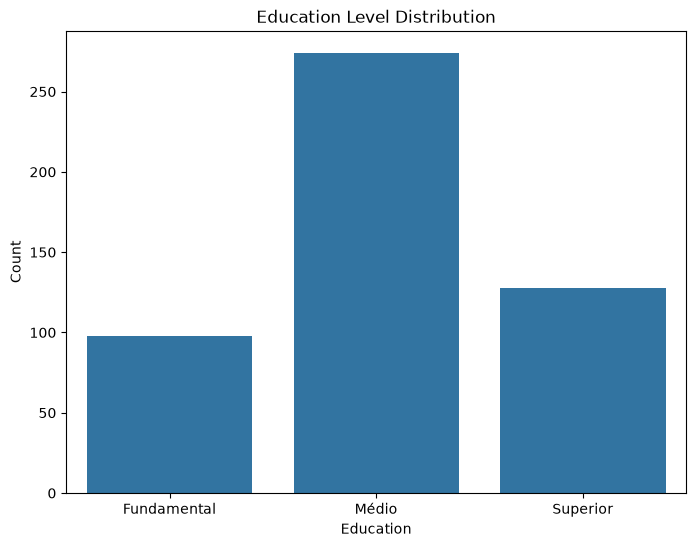

In [25]:
# plot education level distribution
plt.figure(figsize=(8,6))
sns.countplot(data = df_psycho_test, x = "Escolaridade", order = ["Fundamental", "Médio", "Superior"])
plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

## Correlation Between Quantitative Variables

The correlation between quantitative variables allows us to understand how one variable moves in relation to another. 
The most common method for calculating correlation between variables is using Pearson's correlation coefficient, which ranges between -1 and 1.

- The closer to 1, the stronger the positive correlation. 
- The closer to -1, the stronger the negative correlation. 
- Close to 0 indicates little or no correlation. 

Let's calculate the correlation matrix and then visualize it in a heatmap.

In [26]:
# getting numerical columns
numerical_columns = ["Idade", "Salario", "Score_Exame_Psicotecnico"]

In [27]:
numerical_columns

['Idade', 'Salario', 'Score_Exame_Psicotecnico']

In [31]:
# Calculating the correlation matrix only for quantitative variables
correlation_matrix = df_psycho_test[numerical_columns].corr()

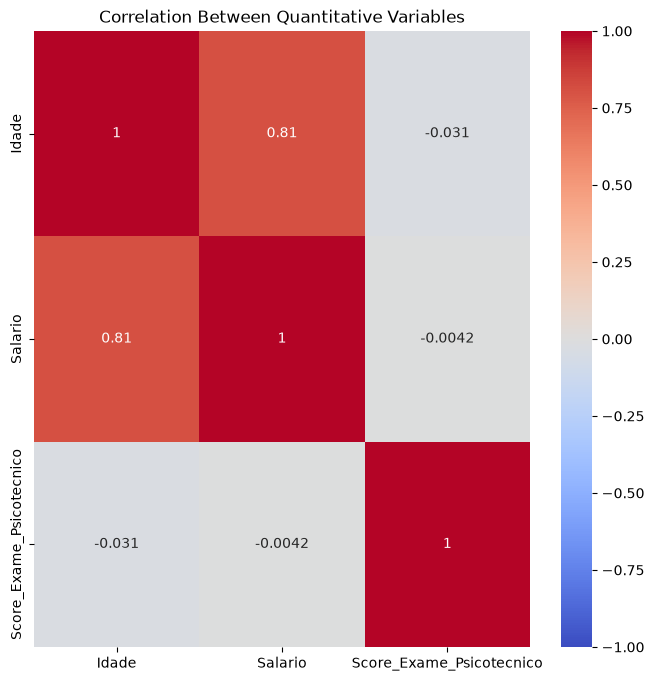

In [32]:
# Visualizing the correlation matrix with a heatmap
plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin = -1, vmax = 1)
plt.title("Correlation Between Quantitative Variables")
plt.show()

## Association Between Qualitative Variables

For categorical variables, we use association (and not correlation) to analyze the relationship between variables. Let's look at some association techniques. 

#### Contingency Table:

It is basically a cross-tabulation (crosstab) that shows the frequency (or count) of observations in each category for two variables.

In [34]:
# contingency table
contingency_table = pd.crosstab(df_psycho_test["Genero"], df_psycho_test["Escolaridade"])

In [35]:
print(contingency_table)

Escolaridade  Fundamental  Médio  Superior
Genero                                    
Feminino               31     90        48
Masculino              32     95        39
Outro                  35     89        41


#### Chi-Square Test (χ²): 

It is used to test the independence between two categorical variables.The Chi-Square test is a statistical technique used to determine whether there is a significant association between two categorical variables in a dataset. There are several hypotheses associated with the Chi-Square test:


Null Hypothesis (H0): The null hypothesis states that there is no significant association between the two categorical variables in the dataset. In other words, the two variables are independent of each other.


Alternative Hypothesis (H1 or Ha): The alternative hypothesis is the negation of the null hypothesis. It suggests that there is a significant association between the two categorical variables in the dataset. In simple terms, the two variables are not independent.


We apply the test and analyze the p-value. If the p-value is less than a significance level (usually 0.05), we can reject the null hypothesis that the variables are independent.

In [36]:
# load a function chi2_contingency
from scipy.stats import chi2_contingency

In [38]:
# apply a function chi2_contigency
chi2, p, _, _ = chi2_contingency(contingency_table)

In [39]:
print(f"Chi-Square test p-value: {p:.4f}")

Chi-Square test p-value: 0.8300


> > In this case, we fail to reject H0. The two variables are likely independent of each other.

**Conclusion:** There is no relationship between the variables Gender and Education Level.

#### Cramér's V Contingency Coefficient (V): 

Measures the strength of the association between two nominal variables. Its value ranges from 0 (no association) to 1 (perfect association). It is based on the chi-square value.

In [43]:
# Calculating Cramér's contingency coefficient
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))

In [47]:
print(f"Cramér's V coefficient: {cramers_v:.4f}")

Cramér's V coefficient: 0.0385


>> There is no association between the variables.

---
## Data Preprocessing Techniques
---

So far, we have analyzed and explored the data. We use the results of this work to decide the type of preprocessing we should perform. We will start by handling missing values, duplicates, and negative values

## Duplicate Values

In [48]:
# We use the duplicated() method to create a boolean series indicating duplicates
duplicateds = df_psycho_test.duplicated()

In [50]:
# showing duplicate rows
df_psycho_test[duplicateds]

,Idade,Salario,Genero,Escolaridade,Score_Exame_Psicotecnico


>> There aren't duplicate values

## Negative Values

In [51]:
# checking for negative values in the salario column
df_psycho_test[df_psycho_test["Salario"] < 0]

,Idade,Salario,Genero,Escolaridade,Score_Exame_Psicotecnico
94,20,-619.478622,Masculino,Médio,58.0
358,21,-2984.433215,Masculino,Médio,43.0
380,20,-3254.849042,Outro,Médio,50.0
